# XGBoost Multilabel Cascade Prediction
**Binary Relevance with `scale_pos_weight` for class imbalance**

This notebook trains one XGBoost binary classifier per cascade label and provides
visibility into every stage: data exploration, class imbalance, training curves,
feature importance, threshold tuning, and final evaluation.

In [55]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, hamming_loss, jaccard_score,
    precision_recall_curve, confusion_matrix, roc_curve, auc
)
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

%matplotlib inline

## 1. Load Prepared Data

In [56]:
DATA_DIR = Path('../data/chronological_prepared_data')

X_train = np.load(DATA_DIR / 'X_train.npy')
X_test  = np.load(DATA_DIR / 'X_test.npy')
y_train = np.load(DATA_DIR / 'y_train.npy')
y_test  = np.load(DATA_DIR / 'y_test.npy')

with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
target_names  = metadata['target_names']

print(f"Train : {X_train.shape[0]:,} samples, {X_train.shape[1]} features")
print(f"Test  : {X_test.shape[0]:,}  samples")
print(f"Labels: {len(target_names)}")
print(f"Split : {metadata.get('split_type', 'unknown')}")

Train : 773,952 samples, 165 features
Test  : 193,489  samples
Labels: 26
Split : chronological


## 2. Explore Label Distributions & Class Imbalance
Understanding how skewed each label is drives the choice of `scale_pos_weight`.

In [57]:
train_counts = y_train.sum(axis=0)
test_counts  = y_test.sum(axis=0)
train_total  = y_train.shape[0]
test_total   = y_test.shape[0]

label_df = pd.DataFrame({
    'label': target_names,
    'train_pos': train_counts.astype(int),
    'test_pos':  test_counts.astype(int),
    'train_pct': train_counts / train_total * 100,
    'test_pct':  test_counts / test_total * 100,
    'imbalance_ratio': (train_total - train_counts) / np.maximum(train_counts, 1)
}).sort_values('train_pos', ascending=False).reset_index(drop=True)

label_df.style.format({
    'train_pos': '{:,.0f}', 'test_pos': '{:,.0f}',
    'train_pct': '{:.2f}%', 'test_pct': '{:.2f}%',
    'imbalance_ratio': '{:.1f}:1'
}).bar(subset=['train_pct'], color='#5fba7d')

,label,train_pos,test_pos,train_pct,test_pct,imbalance_ratio
0,Thunderstorm Wind,"38,123","9,688",4.93%,5.01%,19.3:1
1,Hail,"37,092","9,749",4.79%,5.04%,19.9:1
2,Flash Flood,"34,048","9,973",4.40%,5.15%,21.7:1
3,Flood,"8,760","1,869",1.13%,0.97%,87.4:1
4,Tornado,"8,409","3,125",1.09%,1.62%,91.0:1
5,Lightning,"5,386","1,101",0.70%,0.57%,142.7:1
6,Excessive Heat,"2,212","3,070",0.29%,1.59%,348.9:1
7,Heat,"1,788","2,406",0.23%,1.24%,431.9:1
8,Extreme Cold/Wind Chill,"1,517",169,0.20%,0.09%,509.2:1
9,Debris Flow,"1,277",292,0.16%,0.15%,605.1:1


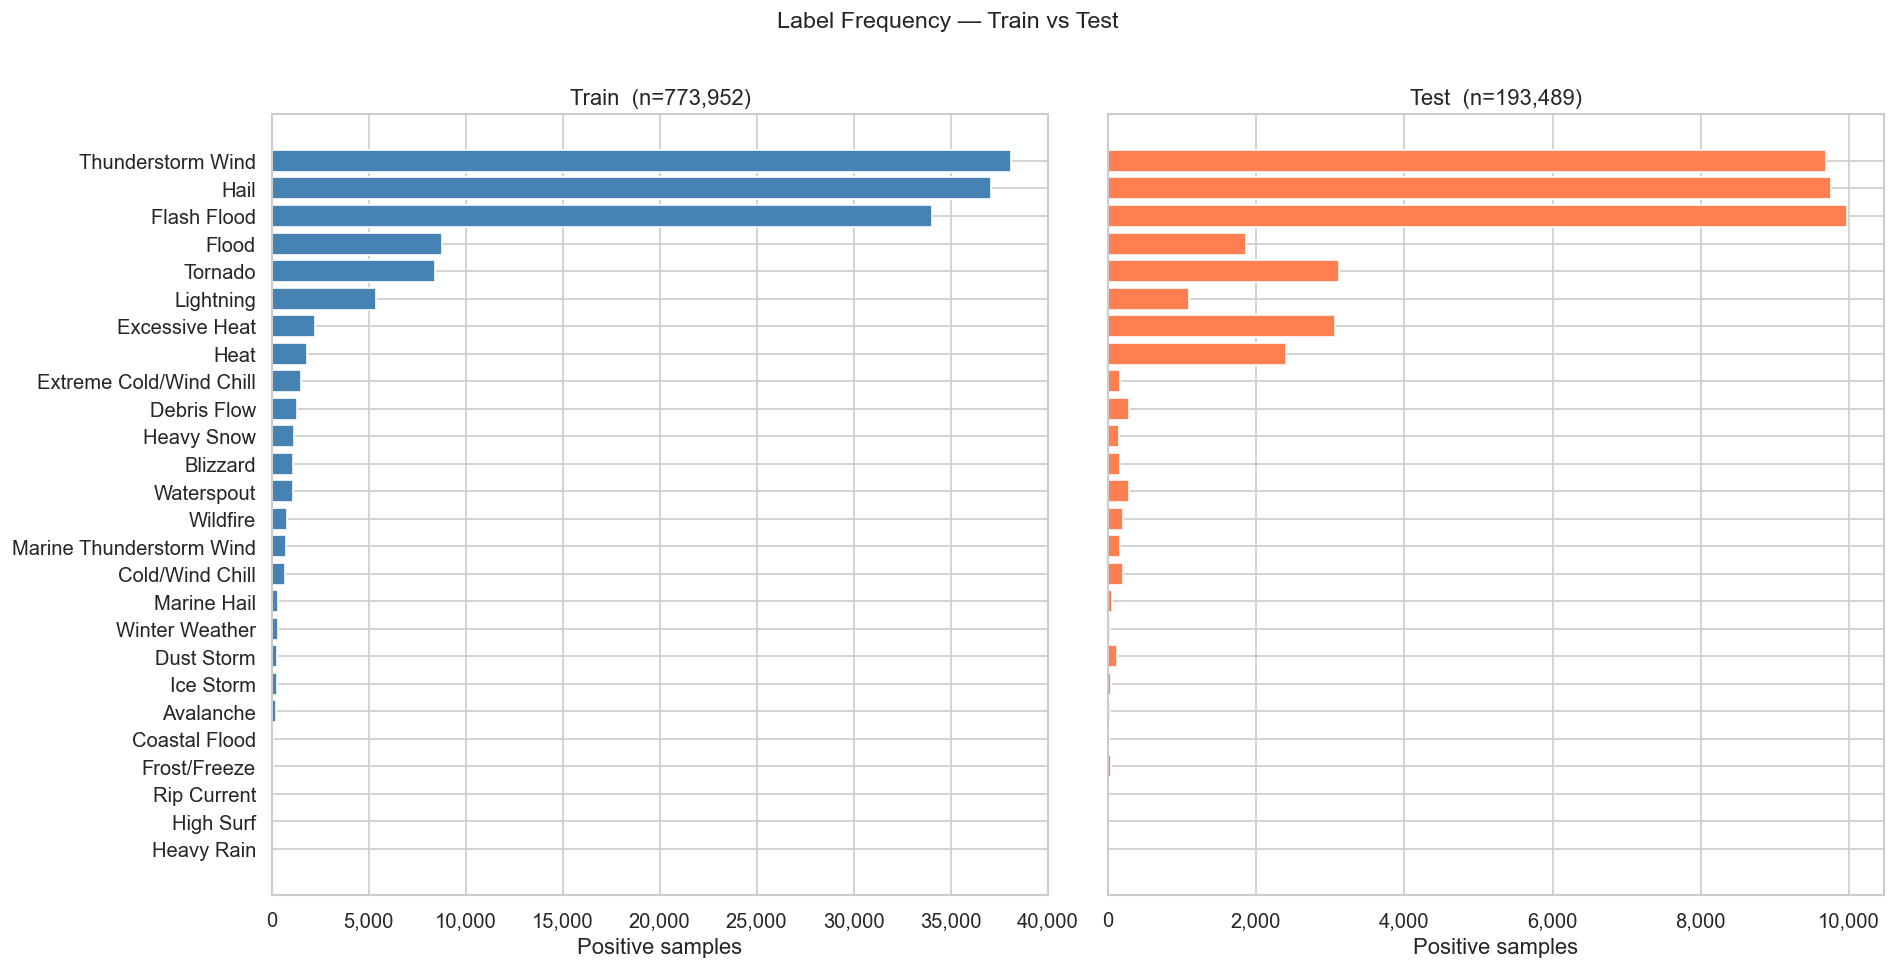

In [58]:
# --- Label frequency: train vs test side-by-side ---
sorted_df = label_df.sort_values('train_pos', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

axes[0].barh(sorted_df['label'], sorted_df['train_pos'], color='steelblue')
axes[0].set_xlabel('Positive samples')
axes[0].set_title(f'Train  (n={train_total:,})')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].barh(sorted_df['label'], sorted_df['test_pos'], color='coral')
axes[1].set_xlabel('Positive samples')
axes[1].set_title(f'Test  (n={test_total:,})')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

fig.suptitle('Label Frequency — Train vs Test', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

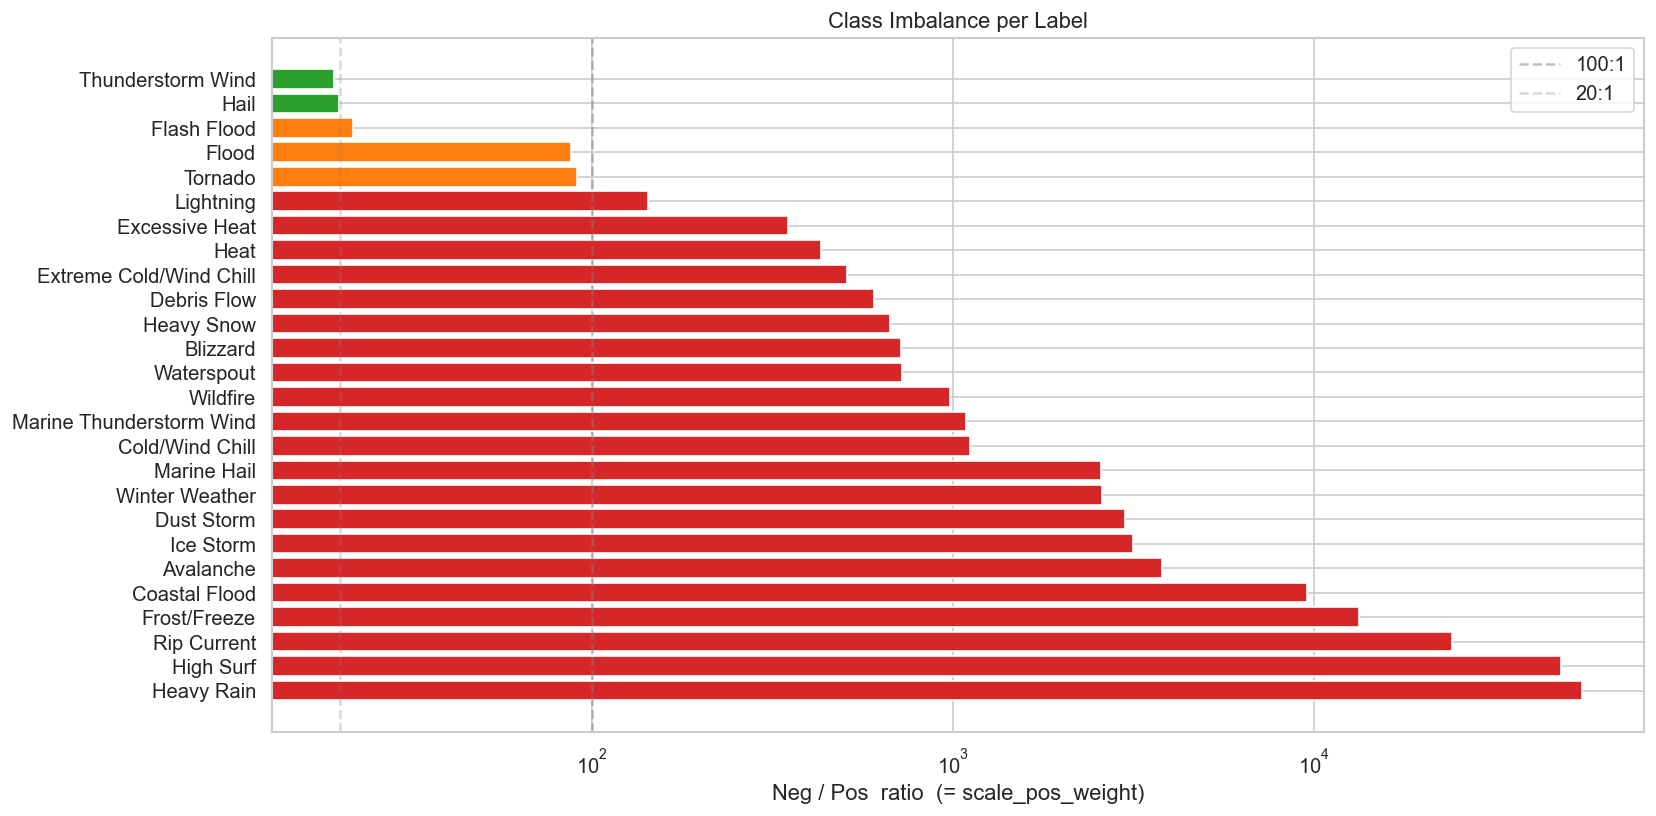

In [59]:
# --- Imbalance ratio (= scale_pos_weight that will be used) ---
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#d62728' if r > 100 else '#ff7f0e' if r > 20 else '#2ca02c'
          for r in sorted_df['imbalance_ratio']]
ax.barh(sorted_df['label'], sorted_df['imbalance_ratio'], color=colors)
ax.set_xlabel('Neg / Pos  ratio  (= scale_pos_weight)')
ax.set_title('Class Imbalance per Label')
ax.set_xscale('log')
ax.axvline(x=100, ls='--', color='gray', alpha=.5, label='100:1')
ax.axvline(x=20,  ls='--', color='gray', alpha=.3, label='20:1')
ax.legend()
plt.tight_layout()
plt.show()

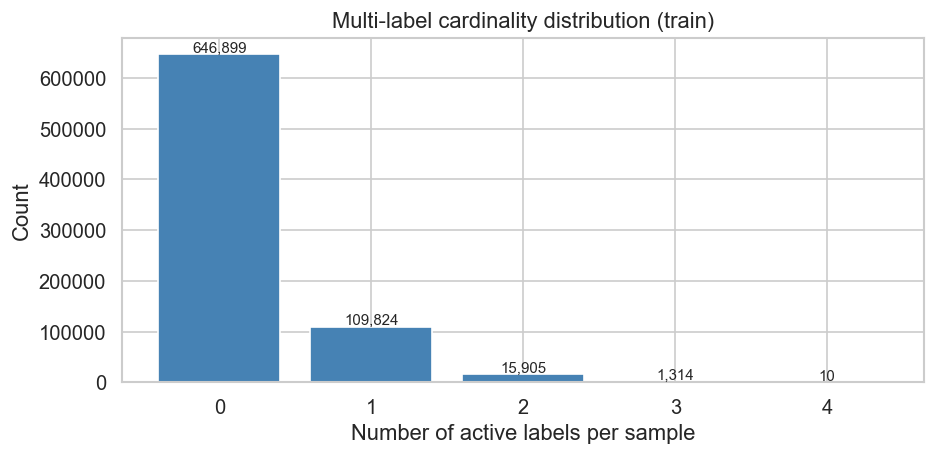

Mean labels per sample: 0.19
Samples with 0 labels : 646,899  (83.6%)


In [60]:
# --- Multi-label co-occurrence ---
labels_per_sample = y_train.sum(axis=1)
fig, ax = plt.subplots(figsize=(8, 4))
counts = pd.Series(labels_per_sample).value_counts().sort_index()
ax.bar(counts.index.astype(int), counts.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of active labels per sample')
ax.set_ylabel('Count')
ax.set_title('Multi-label cardinality distribution (train)')
for i, (x, v) in enumerate(zip(counts.index, counts.values)):
    ax.text(x, v + train_total * 0.005, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Mean labels per sample: {labels_per_sample.mean():.2f}")
print(f"Samples with 0 labels : {(labels_per_sample == 0).sum():,}  "
      f"({(labels_per_sample == 0).mean()*100:.1f}%)")

## 3. Hyperparameter Tuning + Training

**Approach**: Quick randomized search on the top-2 labels (most training
positives), then train all labels with the best-found hyperparameters.

**Key design decisions:**
- **Chronological val split**: The last 10% of training data forms the
  validation set — strictly after the training period, no future leakage.
- **Capped SPW**: `scale_pos_weight = min(n_neg/n_pos, 30)` prevents
  over-prediction of rare labels.
- **MIN_POS_FRAC = 0.05%**: Labels with < 0.05% of training samples are dropped.
- **Negative subsampling**: For each label, negatives are down-sampled to 5× the
  positives for faster, more balanced training (full data still used for eval).
- **Per-label threshold tuning on val set** — each label gets its own optimal
  threshold that maximises its F1. Never tuned on test data.

**Timeline**: `[--- Train ---][-- Val --][---- Test ----]`

**Note on chronological shift**: The test set covers more recent years where
heat events are significantly more prevalent (Excessive Heat: ~1.8% train
→ ~8.7% test). This is realistic but harder.

In [61]:
from sklearn.model_selection import ParameterSampler

MAX_SPW = 30              # cap scale_pos_weight to avoid over-predicting rare labels
MIN_POS_FRAC = 0.0005     # skip labels with < 0.05% of training samples
NEG_SUBSAMPLE_RATIO = 5   # keep at most 5× negatives per positive during training

# Shared (fixed) params
FIXED_PARAMS = dict(
    objective='binary:logistic',
    eval_metric=['logloss', 'aucpr'],
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=30,
)

# Hyperparameter search grid
PARAM_GRID = {
    'max_depth':        [4, 5, 6, 7, 8],
    'learning_rate':    [0.01, 0.05, 0.1],
    'n_estimators':     [300, 500],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.7, 0.8],
    'min_child_weight': [1, 5, 10],
    'gamma':            [0.0, 1.0, 2.0],
    'reg_alpha':        [0.0, 0.1, 1.0],
    'reg_lambda':       [1.0, 2.0, 5.0],
}

N_SEARCH_ITER = 12  # fast search

In [62]:
# --- Chronological validation split (tail-end of training data) ---
# Since prepare_data already sorted train chronologically, the last 10%
# of X_train IS the most recent slice — no future leakage possible.
val_size = 0.1
split_idx = int(len(X_train) * (1 - val_size))

X_tr  = X_train[:split_idx]
y_tr  = y_train[:split_idx]
X_val = X_train[split_idx:]
y_val = y_train[split_idx:]

print(f"Training   : {X_tr.shape[0]:,}  (earliest events)")
print(f"Validation : {X_val.shape[0]:,}  (tail-end of train period)")
print(f"Test       : {X_test.shape[0]:,}  (most recent events)")
print(f"Features   : {X_tr.shape[1]}")
print(f"\nTimeline:  [--- Train ---][-- Val --][---- Test ----]")
print(f"           No data leakage: val & test are strictly after train.")

Training   : 696,556  (earliest events)
Validation : 77,396  (tail-end of train period)
Test       : 193,489  (most recent events)
Features   : 165

Timeline:  [--- Train ---][-- Val --][---- Test ----]
           No data leakage: val & test are strictly after train.


In [ ]:
import time, json

MODEL_DIR = Path('../models/baseline/xgb_models')
CHECKPOINT = MODEL_DIR / '_checkpoint.pkl'

MIN_POS_THRESHOLD = int(len(y_tr) * MIN_POS_FRAC)

# ── Helper: subsample negatives for a single label ─────────────────────
def subsample_negatives(X, y_col, ratio=NEG_SUBSAMPLE_RATIO, seed=42):
    """Keep all positives + up to `ratio` × n_pos negatives."""
    pos_idx = np.where(y_col == 1)[0]
    neg_idx = np.where(y_col == 0)[0]
    n_keep = min(len(neg_idx), ratio * len(pos_idx))
    rng = np.random.RandomState(seed)
    neg_keep = rng.choice(neg_idx, size=int(n_keep), replace=False)
    keep = np.sort(np.concatenate([pos_idx, neg_keep]))
    return X[keep], y_col[keep]

# ── Try loading cached models ──────────────────────────────────────────
if CHECKPOINT.exists():
    print(f"Found checkpoint at {CHECKPOINT}")
    with open(CHECKPOINT, 'rb') as f:
        ckpt = pickle.load(f)
    best_params       = ckpt['best_params']
    training_summary  = ckpt['training_summary']
    eval_histories    = ckpt['eval_histories']
    trainable         = ckpt['trainable']

    models = {}
    for label_file in sorted(MODEL_DIR.glob('*.json')):
        label = label_file.stem
        mdl = XGBClassifier()
        mdl.load_model(str(label_file))
        models[label] = mdl

    print(f"  Loaded {len(models)} cached models — skipping training.")
    print(f"  Best params: {best_params}")
    print(f"  (Delete {MODEL_DIR}/ to retrain from scratch)\n")

else:
    # ── Step 1: Identify trainable labels ──────────────────────────────
    print(f"MIN_POS_FRAC = {MIN_POS_FRAC}  →  minimum {MIN_POS_THRESHOLD:,} positive samples "
          f"(out of {len(y_tr):,} train rows)\n")

    trainable = []
    for i, label in enumerate(target_names):
        n_pos = int(y_tr[:, i].sum())
        if n_pos >= MIN_POS_THRESHOLD:
            trainable.append((i, label, n_pos))
        else:
            print(f"  DROP  {label:30s}  (pos={n_pos:>6,}, "
                  f"{n_pos/len(y_tr)*100:.4f}% < {MIN_POS_FRAC*100:.2f}%)")

    print(f"\nTrainable labels: {len(trainable)} / {len(target_names)}")

    # ── Step 2: Quick hyperparameter search on top-2 labels ────────────
    tuning_labels = sorted(trainable, key=lambda x: -x[2])[:2]
    sampled_params = list(ParameterSampler(PARAM_GRID, n_iter=N_SEARCH_ITER, random_state=42))

    print(f"\nHyperparameter search ({N_SEARCH_ITER} configs) on: "
          f"{[l for _, l, _ in tuning_labels]}")
    t0 = time.time()

    best_params = None
    best_avg_score = -1

    for j, p in enumerate(sampled_params):
        scores = []
        for idx, label, n_pos in tuning_labels:
            X_sub, y_sub = subsample_negatives(X_tr, y_tr[:, idx])
            spw = min(int((y_sub == 0).sum()) / max(int((y_sub == 1).sum()), 1), MAX_SPW)
            clf = XGBClassifier(**p, **FIXED_PARAMS, scale_pos_weight=spw)
            clf.fit(X_sub, y_sub, eval_set=[(X_val, y_val[:, idx])], verbose=False)
            scores.append(clf.evals_result()['validation_0']['aucpr'][clf.best_iteration])
        avg = np.mean(scores)
        if avg > best_avg_score:
            best_avg_score = avg
            best_params = p
        print(f"  [{j+1:2d}/{N_SEARCH_ITER}]  avg_val_aucpr={avg:.4f}  "
              f"{'← best' if avg == best_avg_score else ''}")

    print(f"\nSearch done in {time.time()-t0:.0f}s. Best avg val AUCPR: {best_avg_score:.4f}")
    print("Best params:")
    for k, v in best_params.items():
        print(f"  {k:20s} = {v}")

    # ── Step 3: Train all labels with best params + neg subsampling ────
    models = {}
    eval_histories = {}
    training_summary = []

    n_total_tr = len(y_tr)
    print(f"\nTraining all {len(trainable)} labels with negative subsampling ({NEG_SUBSAMPLE_RATIO}:1)...")
    print(f"  (Full train set: {n_total_tr:,} rows — for each label, we keep all positives")
    print(f"   and randomly sample up to {NEG_SUBSAMPLE_RATIO}× negatives)\n")
    print(f"  {'Label':30s}  {'pos':>6s}  {'neg(sub)':>8s}  {'neg(orig)':>9s}  {'sub%':>5s}  "
          f"{'spw':>5s}  {'round':>5s}  {'val_aucpr':>9s}")
    print("  " + "-" * 100)

    for idx, label, n_pos in trainable:
        y_i_val = y_val[:, idx]
        y_i_tr = y_tr[:, idx]
        n_neg_orig = int((y_i_tr == 0).sum())
        X_sub, y_sub = subsample_negatives(X_tr, y_i_tr)
        n_neg_sub = int((y_sub == 0).sum())
        n_pos_sub = int((y_sub == 1).sum())
        sub_pct = n_neg_sub / max(n_neg_orig, 1) * 100
        spw = min(n_neg_sub / max(n_pos_sub, 1), MAX_SPW)

        model = XGBClassifier(**best_params, **FIXED_PARAMS, scale_pos_weight=spw)
        model.fit(
            X_sub, y_sub,
            eval_set=[(X_sub, y_sub), (X_val, y_i_val)],
            verbose=False
        )

        evals = model.evals_result()
        eval_histories[label] = evals
        models[label] = model

        best_round = model.best_iteration if hasattr(model, 'best_iteration') else len(evals['validation_1']['aucpr']) - 1
        best_aucpr = evals['validation_1']['aucpr'][best_round]

        training_summary.append(dict(
            label=label, n_pos=n_pos, n_neg_orig=n_neg_orig, n_neg_sub=n_neg_sub,
            n_train_rows=len(y_sub), scale_pos_weight=round(spw, 1),
            best_round=best_round, best_val_aucpr=round(best_aucpr, 4), status='trained'
        ))
        print(f"  {label:30s}  {n_pos_sub:>6,}  {n_neg_sub:>8,}  {n_neg_orig:>9,}  "
              f"{sub_pct:>4.1f}%  {spw:>5.1f}  {best_round:>5d}  {best_aucpr:>9.4f}")

    # Add dropped labels to summary
    for i, label in enumerate(target_names):
        if label not in models:
            training_summary.append(dict(label=label, n_pos=int(y_tr[:, i].sum()),
                                         n_train_rows=0, scale_pos_weight=None,
                                         best_round=None, best_val_aucpr=None,
                                         status='dropped'))

    print(f"\nTrained {len(models)}/{len(target_names)} models")

    # ── Save checkpoint ────────────────────────────────────────────────
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    for label, mdl in models.items():
        mdl.save_model(str(MODEL_DIR / f'{label}.json'))

    with open(CHECKPOINT, 'wb') as f:
        pickle.dump({
            'best_params': best_params,
            'training_summary': training_summary,
            'eval_histories': eval_histories,
            'trainable': trainable,
        }, f)
    print(f"  Saved models + checkpoint to {MODEL_DIR}/")

MIN_POS_FRAC = 0.0005  →  minimum 348 positive samples (out of 696,556 train rows)

  DROP  Avalanche                       (pos=   161, 0.0231% < 0.05%)
  DROP  Coastal Flood                   (pos=    77, 0.0111% < 0.05%)
  DROP  Dust Storm                      (pos=   156, 0.0224% < 0.05%)
  DROP  Frost/Freeze                    (pos=    57, 0.0082% < 0.05%)
  DROP  Heavy Rain                      (pos=    14, 0.0020% < 0.05%)
  DROP  High Surf                       (pos=    15, 0.0022% < 0.05%)
  DROP  Ice Storm                       (pos=   193, 0.0277% < 0.05%)
  DROP  Marine Hail                     (pos=   284, 0.0408% < 0.05%)
  DROP  Rip Current                     (pos=    32, 0.0046% < 0.05%)
  DROP  Winter Weather                  (pos=   263, 0.0378% < 0.05%)

Trainable labels: 16 / 26

Hyperparameter search (12 configs) on: ['Thunderstorm Wind', 'Hail']
  [ 1/12]  avg_val_aucpr=0.6393  ← best
  [ 2/12]  avg_val_aucpr=0.6294  
  [ 3/12]  avg_val_aucpr=0.6179  
  [ 4/12]  

In [64]:
summary_df = pd.DataFrame(training_summary)
summary_df.sort_values('best_val_aucpr', ascending=False, na_position='last')

,label,n_pos,n_neg_orig,n_neg_sub,n_train_rows,scale_pos_weight,best_round,best_val_aucpr,status
12,Thunderstorm Wind,35227,661329.0,176135.0,211362,5.0,87.0,0.7320,trained
8,Heat,1288,695268.0,6440.0,7728,5.0,105.0,0.6610,trained
7,Hail,34133,662423.0,170665.0,204798,5.0,102.0,0.5488,trained
14,Waterspout,982,695574.0,4910.0,5892,5.0,90.0,0.5025,trained
6,Flood,8111,688445.0,40555.0,48666,5.0,140.0,0.4735,trained
3,Excessive Heat,1723,694833.0,8615.0,10338,5.0,66.0,0.4661,trained
5,Flash Flood,32029,664527.0,160145.0,192174,5.0,163.0,0.4339,trained
11,Marine Thunderstorm Wind,640,695916.0,3200.0,3840,5.0,11.0,0.3130,trained
2,Debris Flow,941,695615.0,4705.0,5646,5.0,34.0,0.2730,trained
4,Extreme Cold/Wind Chill,1357,695199.0,6785.0,8142,5.0,63.0,0.2133,trained


## 4. Training Curves
Logloss and AUCPR on train vs. validation across boosting rounds.  
Watch for the gap between train & val — a widening gap signals overfitting.

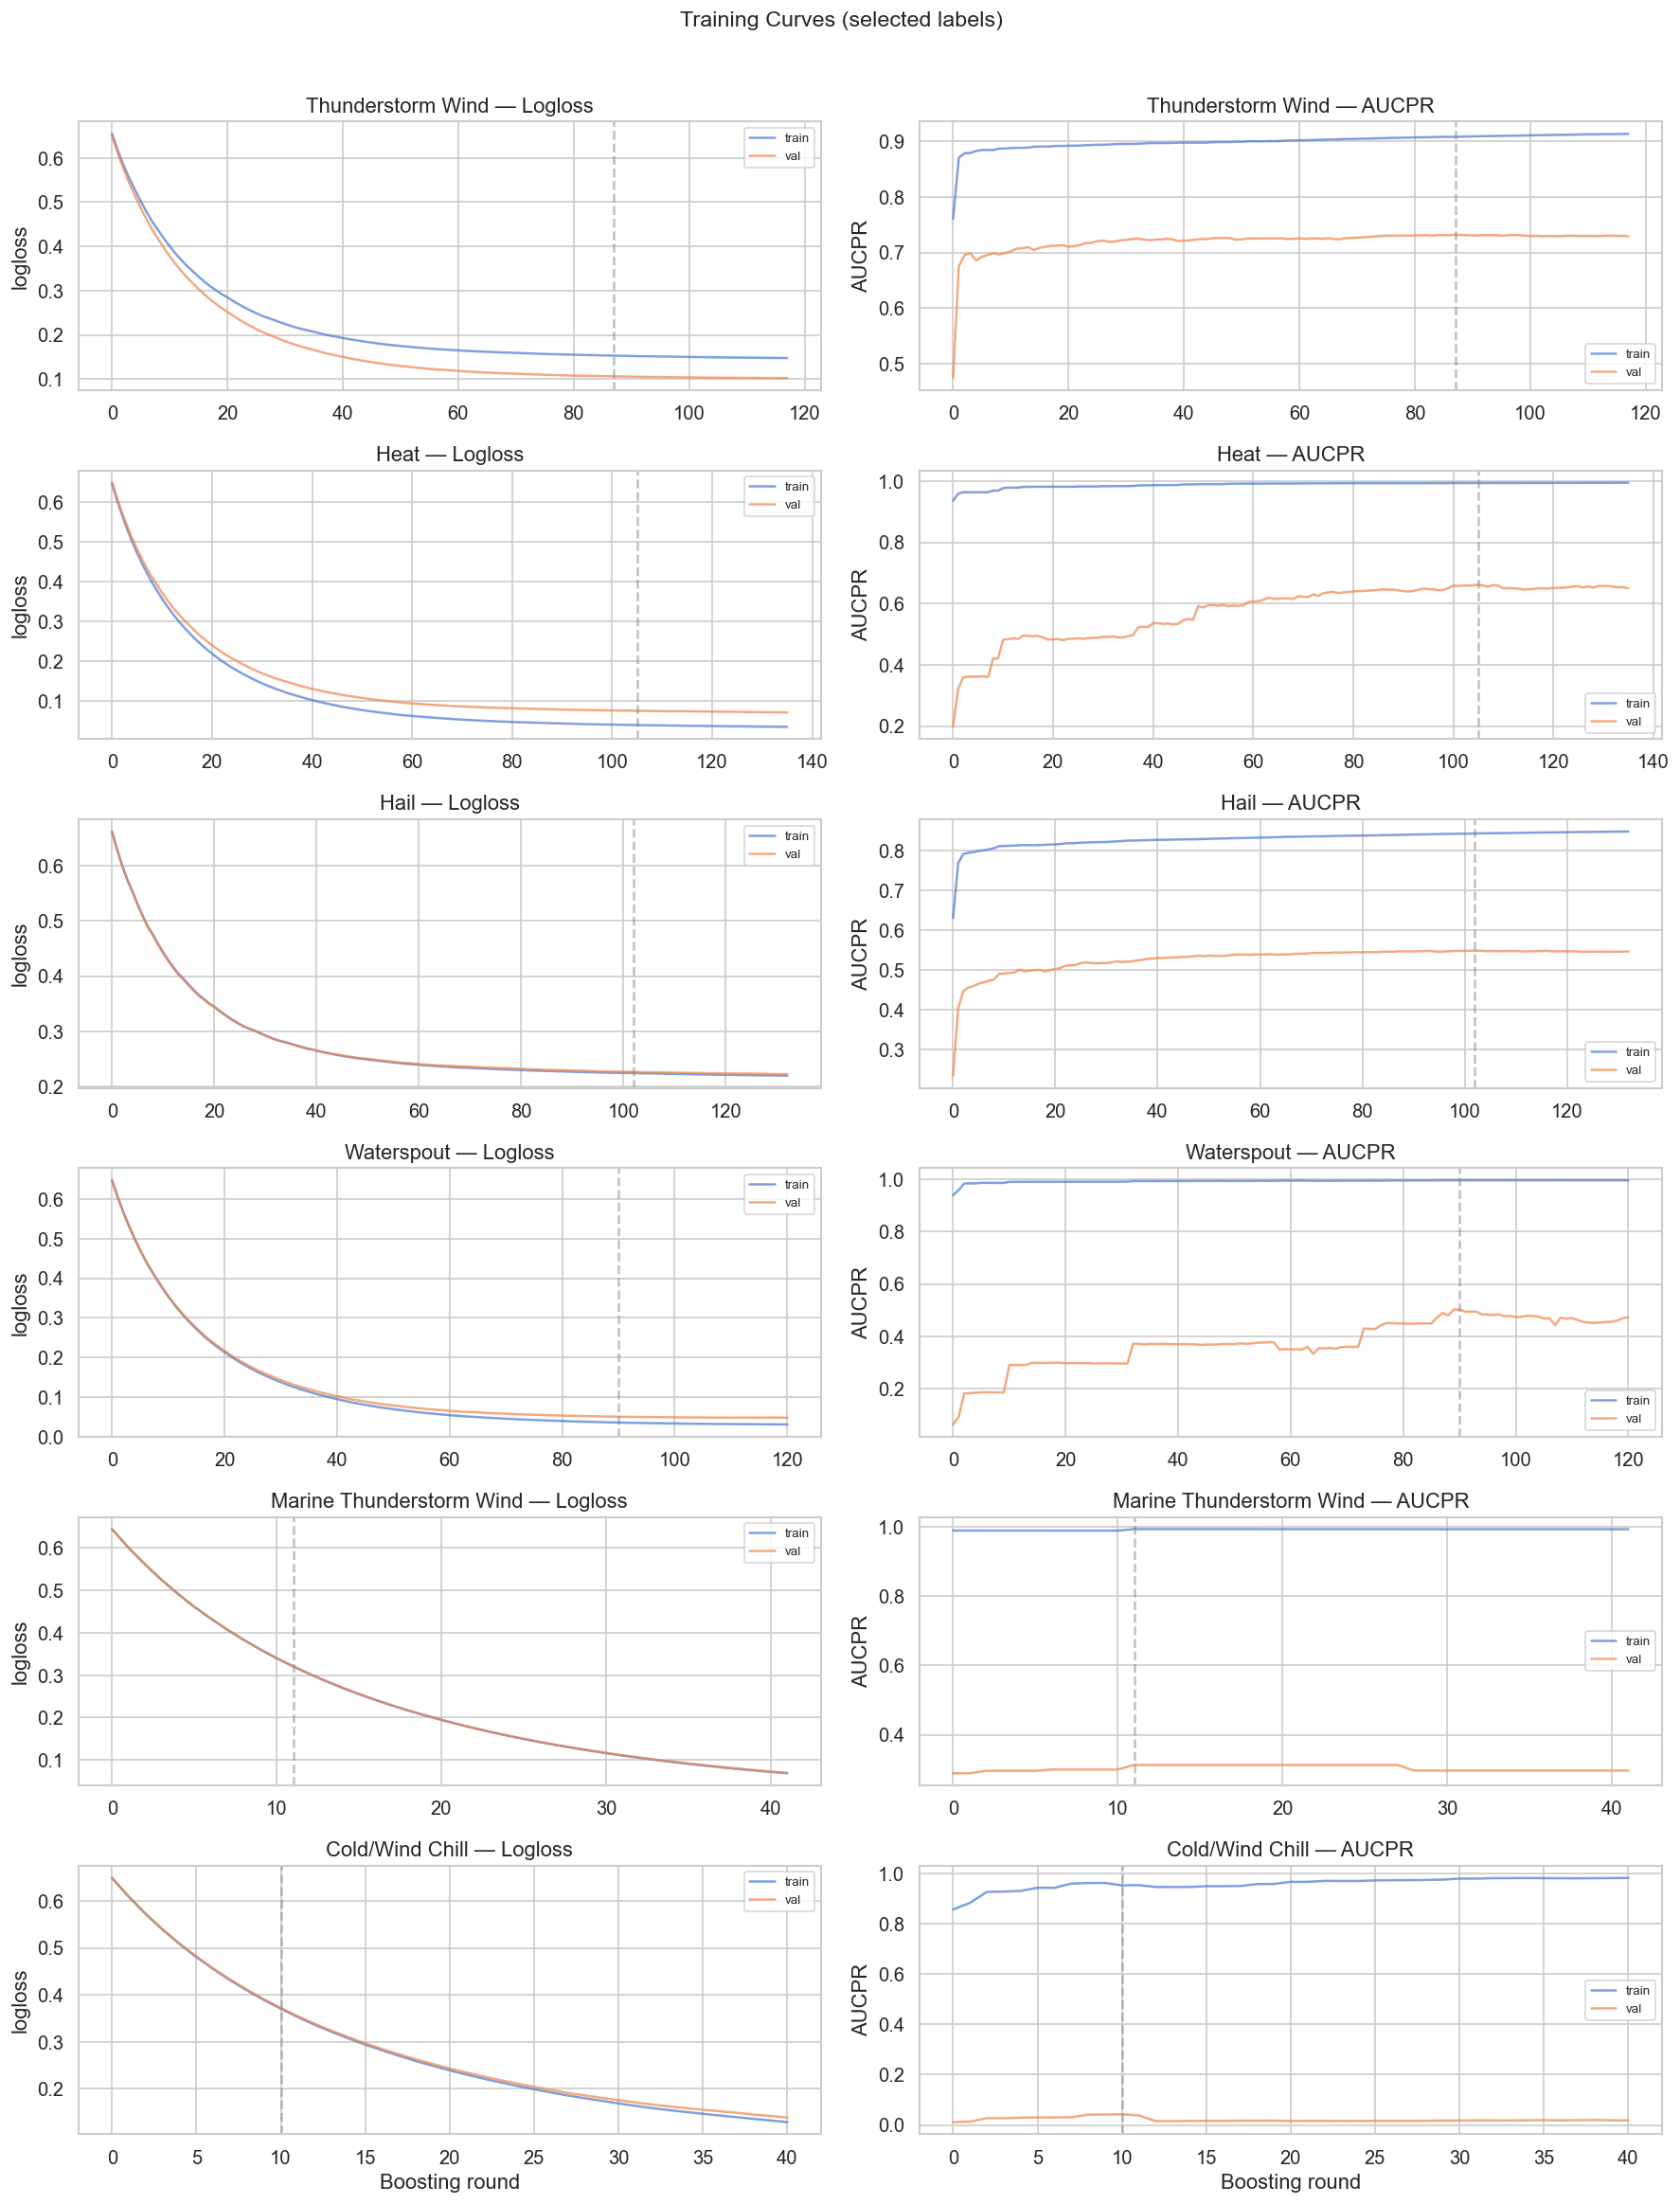

In [65]:
# Pick labels with highest val AUCPR to visualise (plus a few rare ones)
trained = summary_df[summary_df['status'] == 'trained'].copy()
top_labels   = trained.nlargest(4, 'best_val_aucpr')['label'].tolist()
rare_labels  = trained.nsmallest(2, 'n_pos')['label'].tolist()
plot_labels  = list(dict.fromkeys(top_labels + rare_labels))  # dedupe, keep order

n = len(plot_labels)
fig, axes = plt.subplots(n, 2, figsize=(15, 3.2 * n), sharex=False)
if n == 1:
    axes = axes.reshape(1, -1)

for row, label in enumerate(plot_labels):
    h = eval_histories[label]
    rounds = np.arange(len(h['validation_0']['logloss']))
    best_r = summary_df.loc[summary_df['label'] == label, 'best_round'].values[0]

    # Logloss
    ax = axes[row, 0]
    ax.plot(rounds, h['validation_0']['logloss'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['logloss'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('logloss')
    ax.set_title(f'{label} — Logloss')
    ax.legend(fontsize=8)

    # AUCPR
    ax = axes[row, 1]
    ax.plot(rounds, h['validation_0']['aucpr'], label='train', alpha=.7)
    ax.plot(rounds, h['validation_1']['aucpr'], label='val', alpha=.7)
    ax.axvline(best_r, ls='--', color='gray', alpha=.5)
    ax.set_ylabel('AUCPR')
    ax.set_title(f'{label} — AUCPR')
    ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Boosting round')

fig.suptitle('Training Curves (selected labels)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Importance
Averaged across all trained per-label models, plus a per-label breakdown for the top labels.

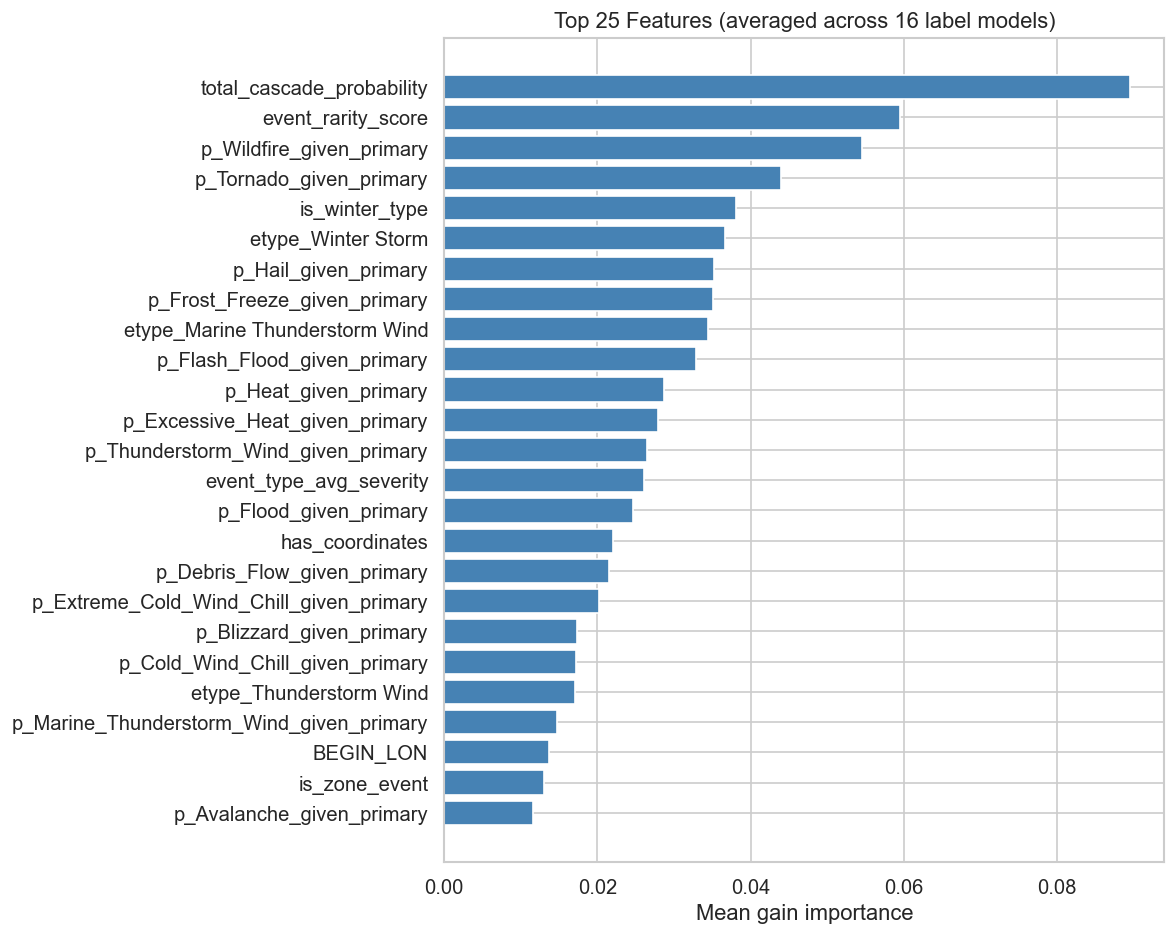

In [66]:
# --- Global average importance ---
imp_matrix = np.zeros((len(models), len(feature_names)))
for j, (lbl, mdl) in enumerate(models.items()):
    imp_matrix[j] = mdl.feature_importances_

avg_imp = imp_matrix.mean(axis=0)
top_k = 25
top_idx = np.argsort(avg_imp)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [feature_names[i] for i in reversed(top_idx)],
    [avg_imp[i] for i in reversed(top_idx)],
    color='steelblue'
)
ax.set_xlabel('Mean gain importance')
ax.set_title(f'Top {top_k} Features (averaged across {len(models)} label models)')
plt.tight_layout()
plt.show()

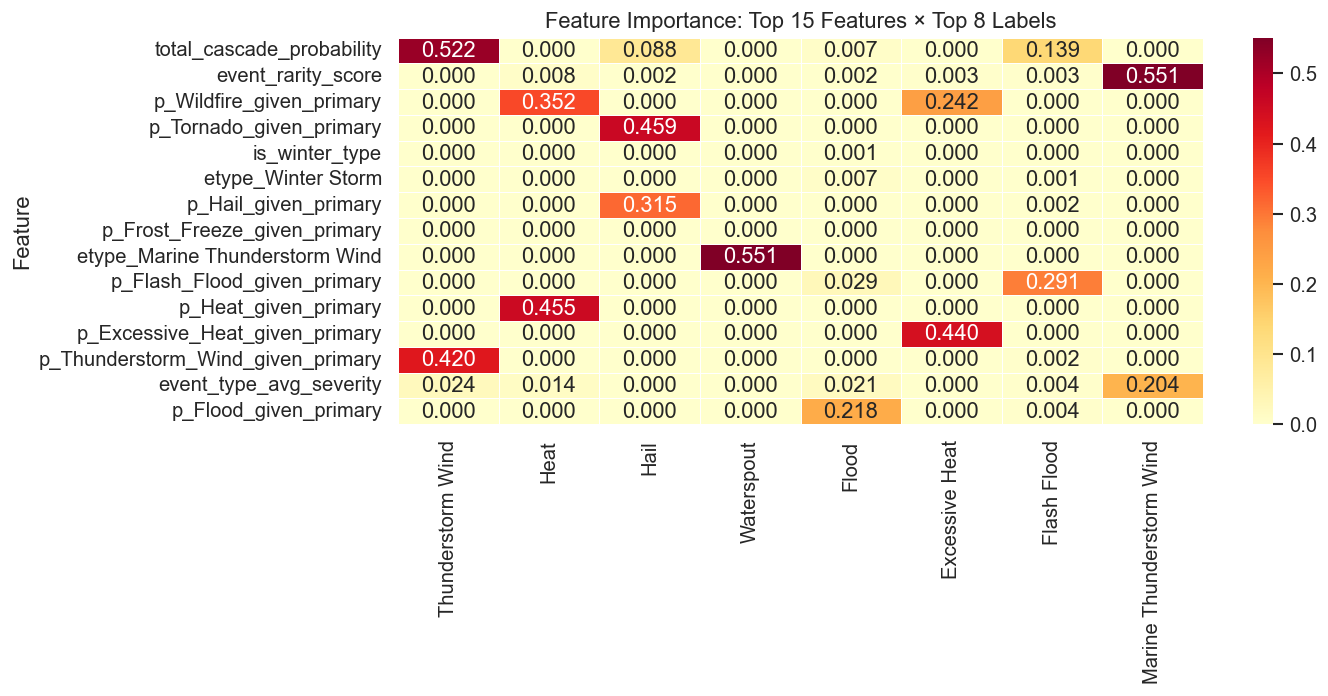

In [67]:
# --- Per-label importance heatmap (top features × top labels) ---
top_labels_for_heatmap = trained.nlargest(8, 'best_val_aucpr')['label'].tolist()
top_feat_idx = top_idx[:15]

heat_data = pd.DataFrame(
    {lbl: models[lbl].feature_importances_[top_feat_idx] for lbl in top_labels_for_heatmap},
    index=[feature_names[i] for i in top_feat_idx]
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax, linewidths=.5)
ax.set_title('Feature Importance: Top 15 Features × Top 8 Labels')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

## 6. Predict, Tune Thresholds & Evaluate
Predict probabilities on validation and test sets, tune per-label thresholds
on the **validation set** (maximise each label's F1 independently), then apply
tuned thresholds to the **test set** and report all metrics.

In [68]:
# ── 6a. Predict probabilities on val + test ────────────────────────────
n_labels = len(target_names)
y_prob = np.zeros((X_test.shape[0], n_labels))
y_prob_val = np.zeros((X_val.shape[0], n_labels))

for i, label in enumerate(target_names):
    if label in models:
        y_prob[:, i] = models[label].predict_proba(X_test)[:, 1]
        y_prob_val[:, i] = models[label].predict_proba(X_val)[:, 1]

# ── 6b. Per-label threshold tuning on validation set ───────────────────
MIN_THRESH = 0.05  # floor to prevent hyper-aggressive thresholds
optimal_thresholds = np.full(n_labels, 0.5)

print("Per-label threshold tuning (maximise F1 per label on val set):\n")
print(f"  {'Label':30s}  {'Thresh':>7s}  {'Val F1@0.5':>10s} -> {'Val F1@opt':>10s}")
print("  " + "-" * 68)

for i, label in enumerate(target_names):
    if label not in models:
        continue
    if int(y_val[:, i].sum()) == 0:
        continue

    precs, recs, threshs = precision_recall_curve(y_val[:, i], y_prob_val[:, i])
    f1s = 2 * precs * recs / (precs + recs + 1e-8)
    best = np.argmax(f1s)
    if best < len(threshs):
        optimal_thresholds[i] = max(threshs[best], MIN_THRESH)

    f1_def = f1_score(y_val[:, i], (y_prob_val[:, i] >= 0.5).astype(int), zero_division=0)
    f1_opt = f1_score(y_val[:, i], (y_prob_val[:, i] >= optimal_thresholds[i]).astype(int), zero_division=0)
    delta = "+" if f1_opt > f1_def else ""
    print(f"  {label:30s}  {optimal_thresholds[i]:7.4f}  {f1_def:10.4f} -> {f1_opt:10.4f}  {delta}")

# ── 6c. Apply tuned thresholds to test set ─────────────────────────────
y_pred = (y_prob >= optimal_thresholds).astype(int)
print(f"\nApplied tuned thresholds to test set ({X_test.shape[0]:,} samples).")

Per-label threshold tuning (maximise F1 per label on val set):

  Label                            Thresh  Val F1@0.5 -> Val F1@opt
  --------------------------------------------------------------------
  Blizzard                         0.9002      0.0754 ->     0.2295  +
  Cold/Wind Chill                  0.7048      0.0157 ->     0.1375  +
  Debris Flow                      0.9077      0.1211 ->     0.4094  +
  Excessive Heat                   0.9701      0.2458 ->     0.4868  +
  Extreme Cold/Wind Chill          0.9547      0.1878 ->     0.2599  +
  Flash Flood                      0.8773      0.2221 ->     0.4237  +
  Flood                            0.9401      0.2558 ->     0.4855  +
  Hail                             0.8971      0.3802 ->     0.5532  +
  Heat                             0.9888      0.3181 ->     0.6110  +
  Heavy Snow                       0.9488      0.0571 ->     0.1201  +
  Lightning                        0.8544      0.0599 ->     0.1482  +
  Marine Thunder

In [69]:
trained_labels = sorted(models.keys())
trained_idx = [i for i, lbl in enumerate(target_names) if lbl in models]

def compute_all_metrics(y_true, y_pred, y_prob, label_names, col_idx):
    """Compute overall + per-label metrics for the given label columns only."""
    yt = y_true[:, col_idx]
    yp = y_pred[:, col_idx]
    ypr = y_prob[:, col_idx]

    overall = {
        'f1_weighted':        f1_score(yt, yp, average='weighted', zero_division=0),
        'precision_weighted': precision_score(yt, yp, average='weighted', zero_division=0),
        'recall_weighted':    recall_score(yt, yp, average='weighted', zero_division=0),
        'f1_macro':           f1_score(yt, yp, average='macro',    zero_division=0),
        'f1_micro':           f1_score(yt, yp, average='micro',    zero_division=0),
        'precision_macro':    precision_score(yt, yp, average='macro', zero_division=0),
        'recall_macro':       recall_score(yt, yp, average='macro',    zero_division=0),
        'hamming_loss':       hamming_loss(yt, yp),
        'subset_accuracy':    (yt == yp).all(axis=1).mean(),
    }

    per_label = []
    for j, lbl in enumerate(label_names):
        sup = int(yt[:, j].sum())
        if sup == 0:
            per_label.append(dict(label=lbl, support=0, f1=0, precision=0, recall=0, pr_auc=0))
            continue
        f1   = f1_score(yt[:, j], yp[:, j], zero_division=0)
        prec = precision_score(yt[:, j], yp[:, j], zero_division=0)
        rec  = recall_score(yt[:, j], yp[:, j], zero_division=0)
        try:
            prauc = average_precision_score(yt[:, j], ypr[:, j])
        except Exception:
            prauc = 0.0
        per_label.append(dict(label=lbl, support=sup, f1=f1, precision=prec, recall=rec, pr_auc=prauc))

    return overall, pd.DataFrame(per_label)

overall, perlabel = compute_all_metrics(y_test, y_pred, y_prob, trained_labels, trained_idx)

print(f'=== Overall (tuned thresholds on test set, {len(trained_labels)} trained labels) ===')
print('  ── Weighted (by label support) ──')
for k in ['f1_weighted', 'precision_weighted', 'recall_weighted']:
    print(f'  {k:25s} {overall[k]:.4f}')
print('  ── Macro / Micro ──')
for k in ['f1_macro', 'f1_micro', 'precision_macro', 'recall_macro',
          'hamming_loss', 'subset_accuracy']:
    print(f'  {k:25s} {overall[k]:.4f}')

print('\n=== Per-label ===')
perlabel.sort_values('f1', ascending=False).style.format({
    'support': '{:,}', 'f1': '{:.3f}', 'precision': '{:.3f}',
    'recall': '{:.3f}', 'pr_auc': '{:.3f}'
}).bar(subset=['f1'], color='#5fba7d')

=== Overall (tuned thresholds on test set, 16 trained labels) ===
  ── Weighted (by label support) ──
  f1_weighted               0.4697
  precision_weighted        0.4648
  recall_weighted           0.4969
  ── Macro / Micro ──
  f1_macro                  0.2963
  f1_micro                  0.4650
  precision_macro           0.2874
  recall_macro              0.3620
  hamming_loss              0.0157
  subset_accuracy           0.7971

=== Per-label ===


,label,support,f1,precision,recall,pr_auc
12,Thunderstorm Wind,"9,688",0.696,0.626,0.784,0.717
7,Hail,"9,749",0.544,0.512,0.582,0.551
14,Waterspout,286,0.535,0.566,0.507,0.486
8,Heat,"2,406",0.487,0.601,0.409,0.502
11,Marine Thunderstorm Wind,169,0.462,0.305,0.947,0.304
6,Flood,"1,869",0.454,0.389,0.544,0.450
5,Flash Flood,"9,973",0.358,0.401,0.323,0.364
13,Tornado,"3,125",0.338,0.306,0.377,0.286
3,Excessive Heat,"3,070",0.270,0.397,0.204,0.351
10,Lightning,"1,101",0.157,0.098,0.405,0.087


## 7. Predicted-Probability Distributions
Histograms of predicted P(positive) for actual positives vs negatives.  
A well-calibrated model pushes these apart.

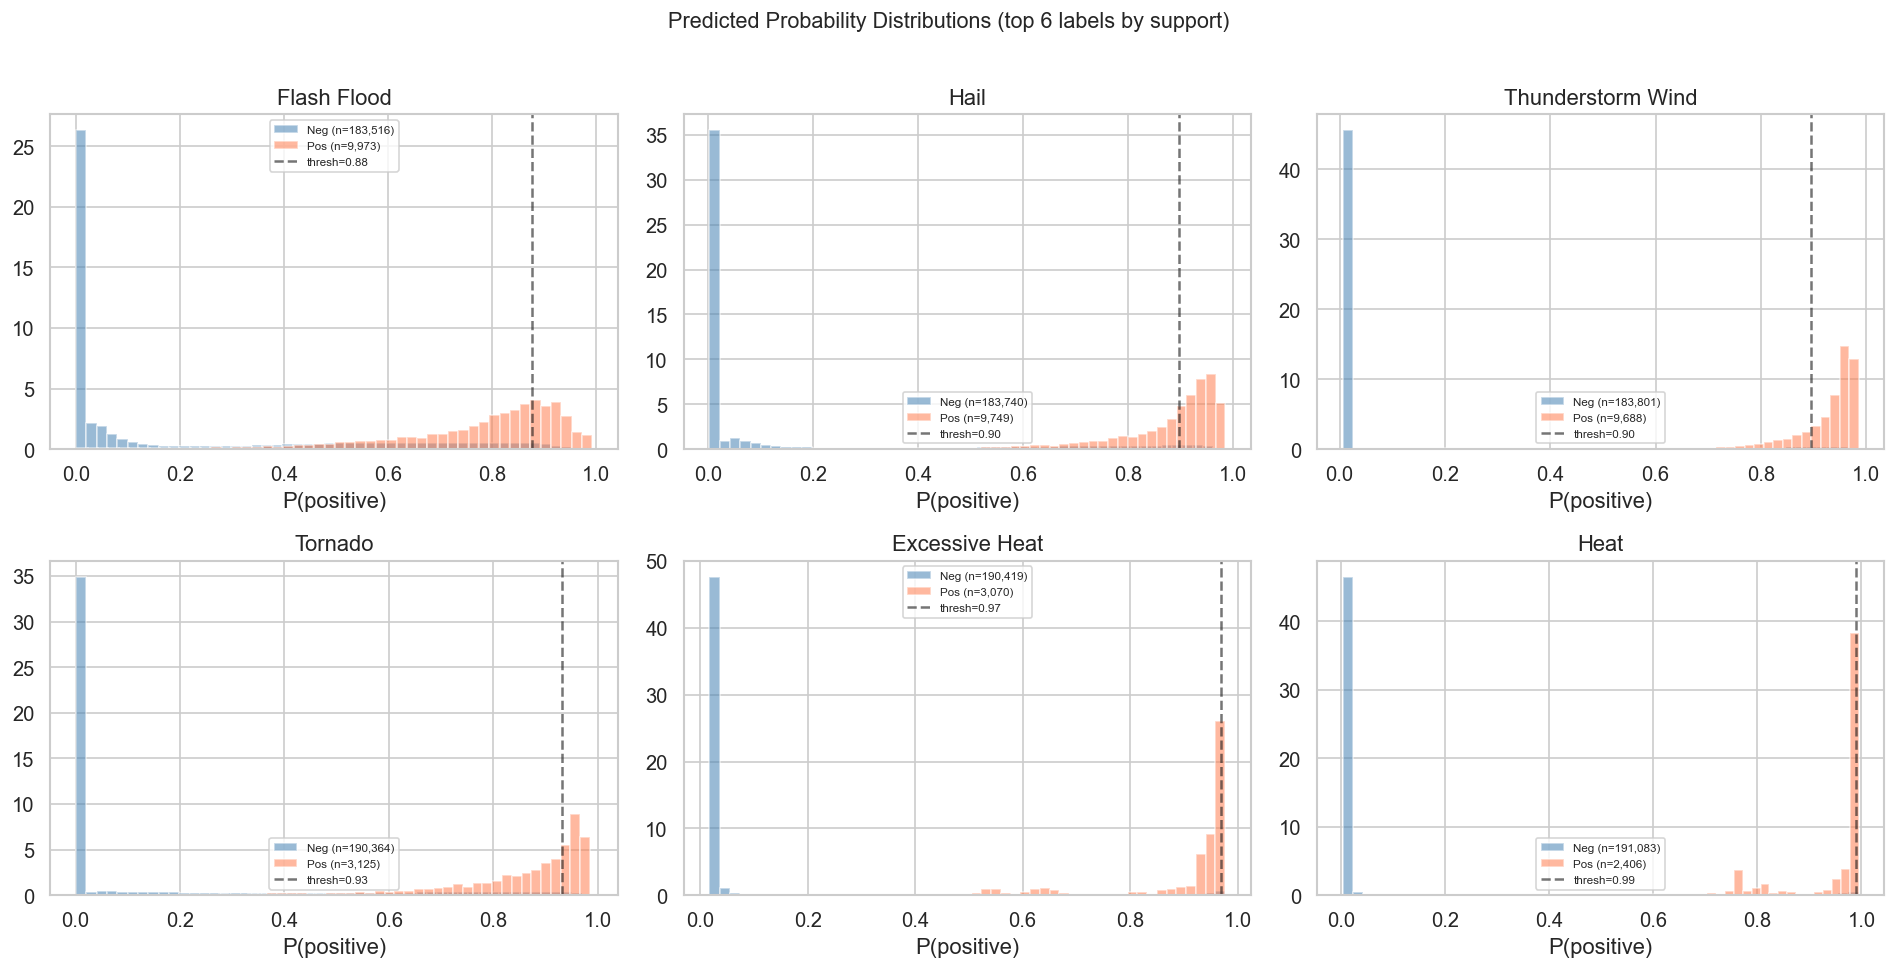

In [70]:
show_labels = perlabel.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.flat, show_labels):
    idx = target_names.index(label)
    pos_probs = y_prob[y_test[:, idx] == 1, idx]
    neg_probs = y_prob[y_test[:, idx] == 0, idx]

    ax.hist(neg_probs, bins=50, alpha=.55, label=f'Neg (n={len(neg_probs):,})', color='steelblue', density=True)
    ax.hist(pos_probs, bins=50, alpha=.55, label=f'Pos (n={len(pos_probs):,})', color='coral', density=True)
    ax.axvline(optimal_thresholds[idx], ls='--', color='k', alpha=.6, label=f'thresh={optimal_thresholds[idx]:.2f}')
    ax.set_title(label)
    ax.set_xlabel('P(positive)')
    ax.legend(fontsize=7)

fig.suptitle('Predicted Probability Distributions (top 6 labels by support)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Tuned Threshold Visualization
The thresholds were tuned in Section 6 above. This chart shows the per-label
decision thresholds selected on the validation set.

In [71]:
# (Threshold tuning was done in Section 6 — this cell intentionally left empty)

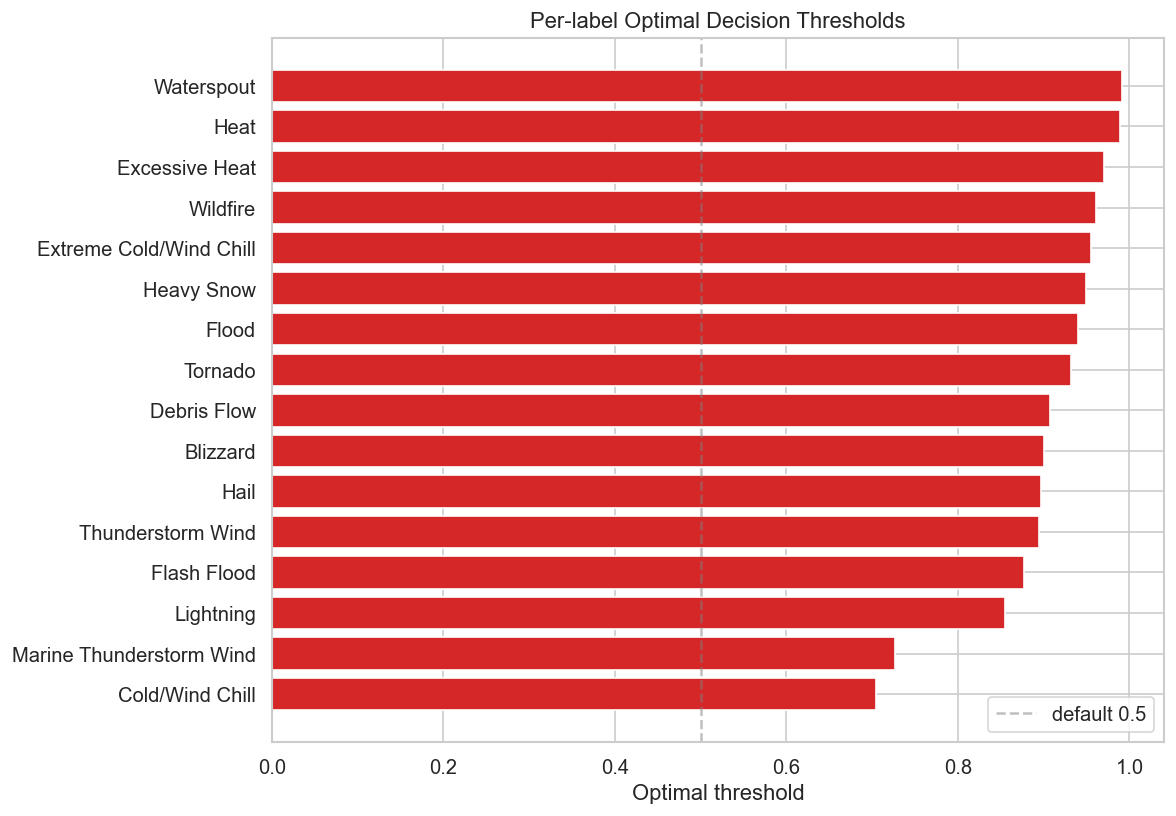

In [72]:
# --- Visualise optimal thresholds (trained labels only) ---
thresh_df = pd.DataFrame({
    'label': [target_names[i] for i in trained_idx],
    'threshold': [optimal_thresholds[i] for i in trained_idx]
})
thresh_df = thresh_df.sort_values('threshold', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#2ca02c' if t < 0.4 else '#ff7f0e' if t < 0.6 else '#d62728'
          for t in thresh_df['threshold']]
ax.barh(thresh_df['label'], thresh_df['threshold'], color=colors)
ax.axvline(0.5, ls='--', color='gray', alpha=.5, label='default 0.5')
ax.set_xlabel('Optimal threshold')
ax.set_title('Per-label Optimal Decision Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Precision-Recall Curves

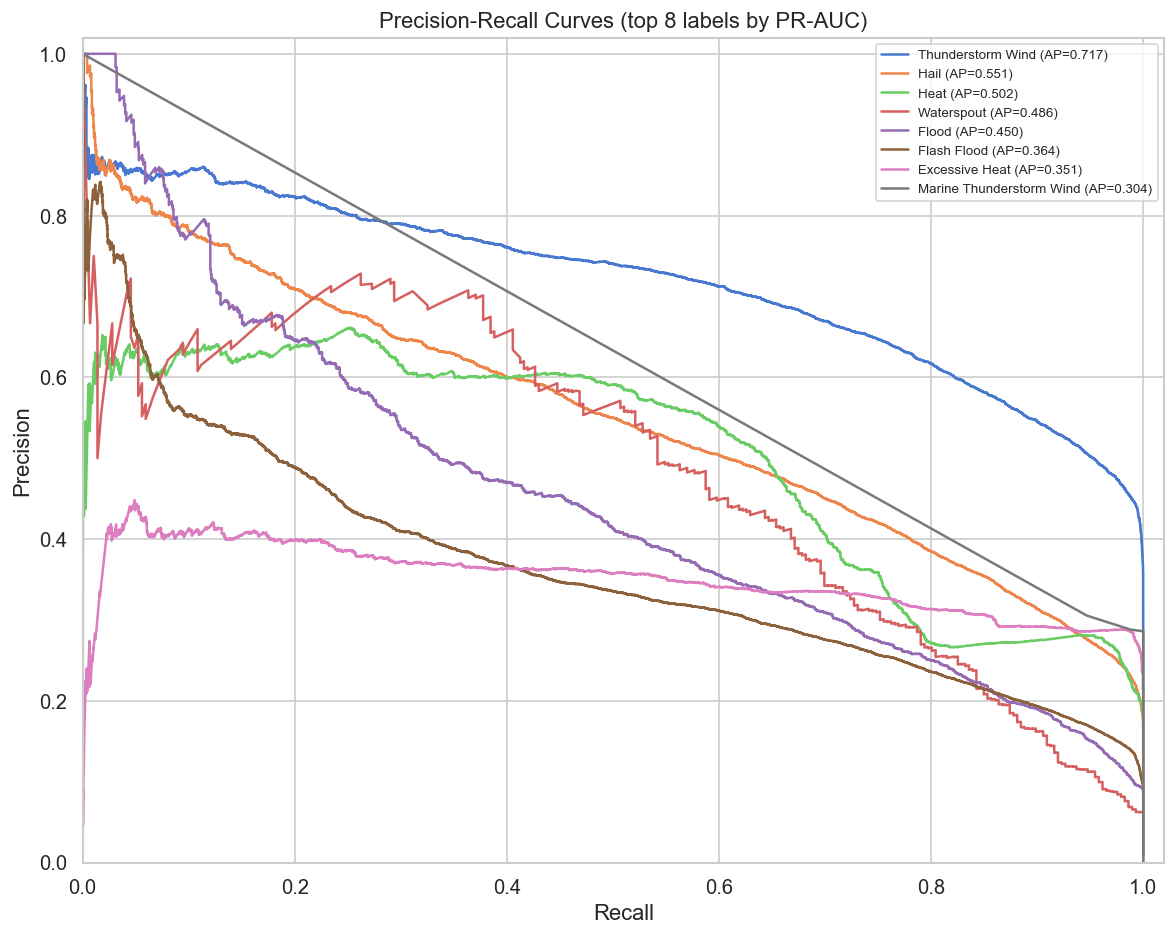

In [73]:
show_pr = perlabel.nlargest(8, 'pr_auc')['label'].tolist()

fig, ax = plt.subplots(figsize=(10, 8))
for label in show_pr:
    idx = target_names.index(label)
    if y_test[:, idx].sum() == 0:
        continue
    precs, recs, _ = precision_recall_curve(y_test[:, idx], y_prob[:, idx])
    ap = average_precision_score(y_test[:, idx], y_prob[:, idx])
    ax.plot(recs, precs, label=f'{label} (AP={ap:.3f})', lw=1.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves (top 8 labels by PR-AUC)')
ax.legend(loc='upper right', fontsize=8)
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 10. Confusion Matrices (top labels)

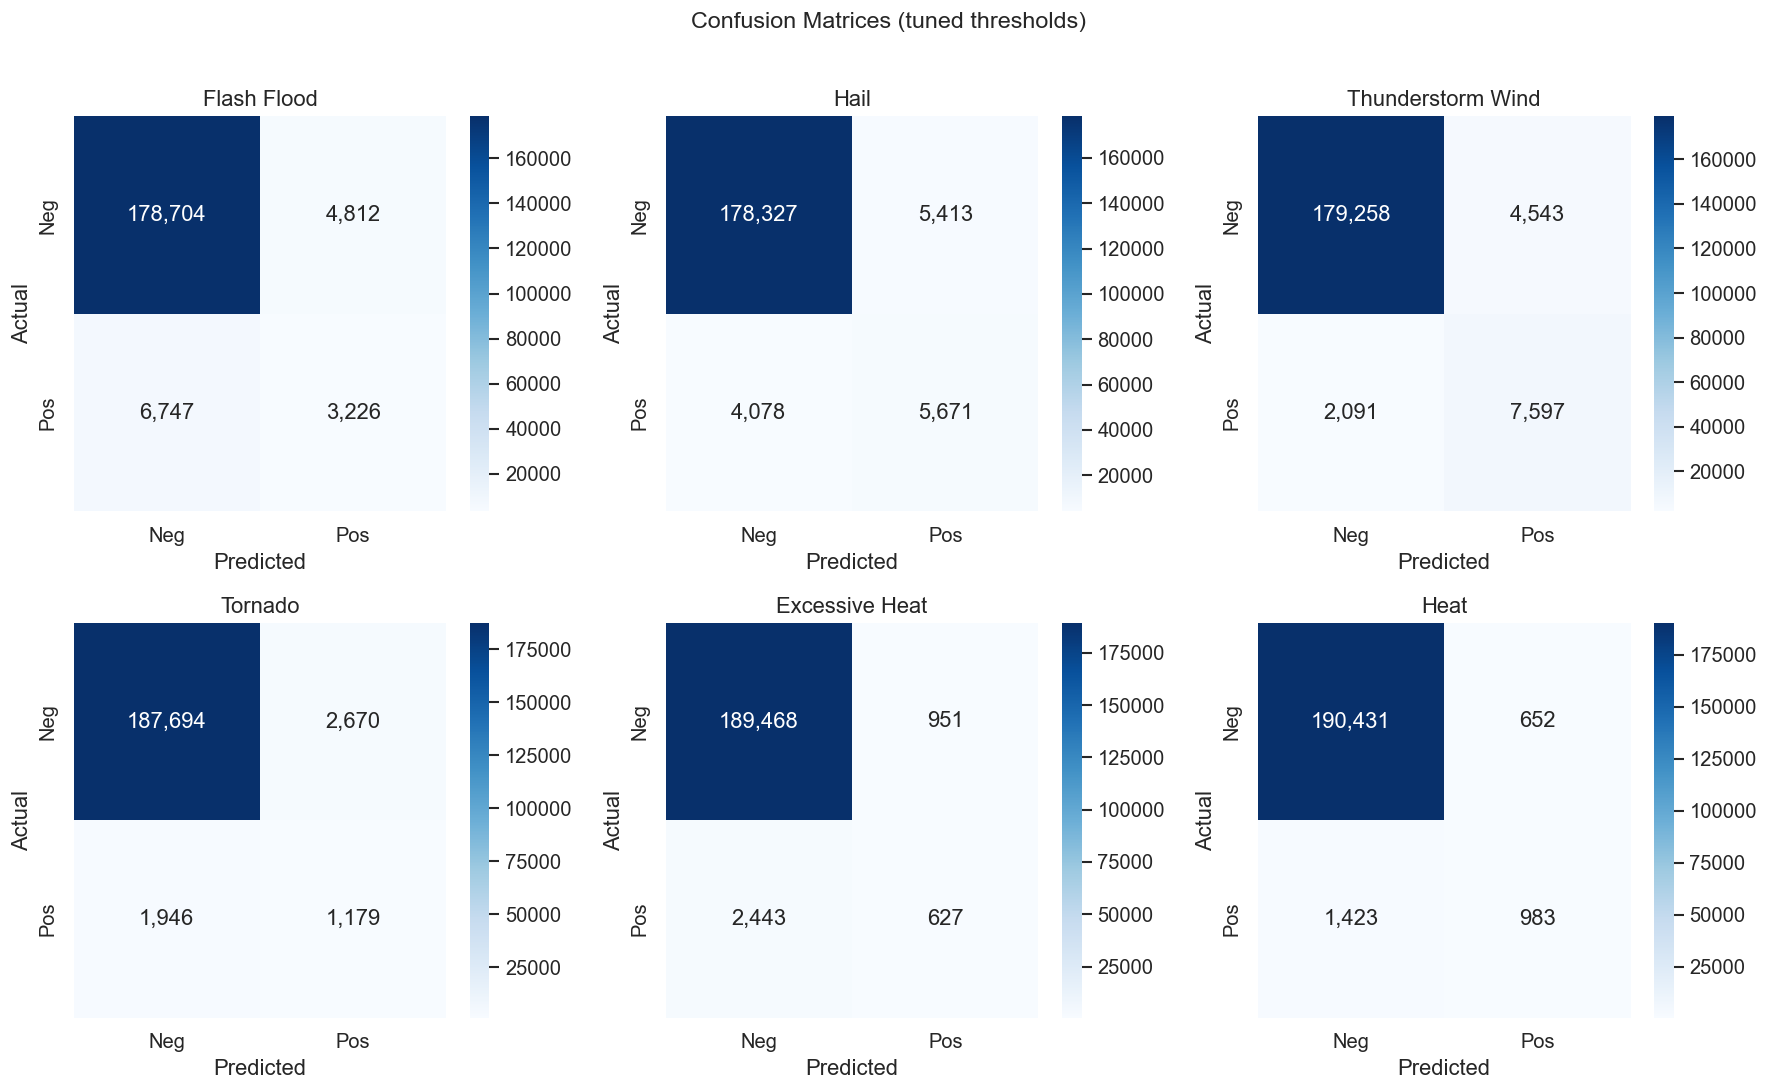

In [74]:
cm_labels = perlabel.nlargest(6, 'support')['label'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, label in zip(axes.flat, cm_labels):
    idx = target_names.index(label)
    cm = confusion_matrix(y_test[:, idx], y_pred[:, idx])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax.set_title(label)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

fig.suptitle('Confusion Matrices (tuned thresholds)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Summary

In [75]:
print('╔════════════════════════════════════════════╗')
print('║     Final Multilabel Results (tuned)      ║')
print('╠════════════════════════════════════════════╣')
for k, v in overall.items():
    print(f'║  {k:28s}  {v:>8.4f}  ║')
print('╚════════════════════════════════════════════╝')

print('\nPer-label breakdown (sorted by F1):')
perlabel.sort_values('f1', ascending=False)

╔════════════════════════════════════════════╗
║     Final Multilabel Results (tuned)      ║
╠════════════════════════════════════════════╣
║  f1_weighted                     0.4697  ║
║  precision_weighted              0.4648  ║
║  recall_weighted                 0.4969  ║
║  f1_macro                        0.2963  ║
║  f1_micro                        0.4650  ║
║  precision_macro                 0.2874  ║
║  recall_macro                    0.3620  ║
║  hamming_loss                    0.0157  ║
║  subset_accuracy                 0.7971  ║
╚════════════════════════════════════════════╝

Per-label breakdown (sorted by F1):


,label,support,f1,precision,recall,pr_auc
12,Thunderstorm Wind,9688,0.696078,0.625783,0.784166,0.716976
7,Hail,9749,0.544425,0.511638,0.581701,0.551371
14,Waterspout,286,0.535055,0.566406,0.506993,0.485510
8,Heat,2406,0.486513,0.601223,0.408562,0.501797
11,Marine Thunderstorm Wind,169,0.461760,0.305344,0.946746,0.304393
6,Flood,1869,0.453774,0.389421,0.543606,0.450424
5,Flash Flood,9973,0.358226,0.401344,0.323473,0.363986
13,Tornado,3125,0.338113,0.306313,0.377280,0.286076
3,Excessive Heat,3070,0.269793,0.397338,0.204235,0.351205
10,Lightning,1101,0.157291,0.097593,0.405086,0.087354


### Per-label F1 bar chart

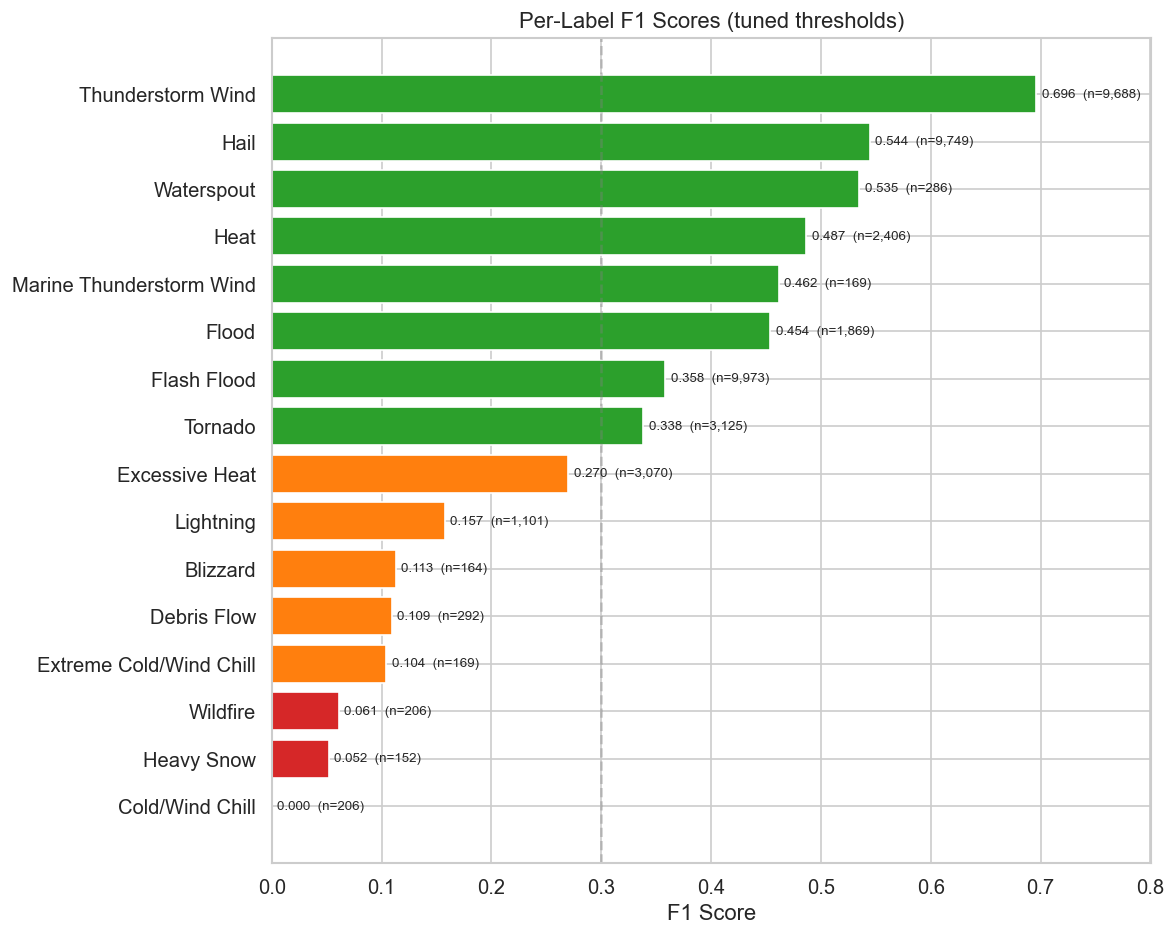

In [76]:
df_final = perlabel.sort_values('f1', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2ca02c' if f >= 0.3 else '#ff7f0e' if f >= 0.1 else '#d62728' for f in df_final['f1']]
ax.barh(df_final['label'], df_final['f1'], color=colors)
ax.set_xlabel('F1 Score')
ax.set_title('Per-Label F1 Scores (tuned thresholds)')
ax.axvline(0.3, ls='--', color='gray', alpha=.4)
ax.set_xlim(0, max(df_final['f1'].max() * 1.15, 0.5))

for i, (f1, sup) in enumerate(zip(df_final['f1'], df_final['support'])):
    ax.text(f1 + 0.005, i, f'{f1:.3f}  (n={sup:,})', va='center', fontsize=8)

plt.tight_layout()
plt.show()